# Rookie Shot Selection Analysis: Cooper Flagg vs. Dylan Harper vs. Kon Knueppel

## Objective

This project compares the 2025-26 NBA regular-season shot profiles of Cooper Flagg, Dylan Harper, and Kon Knueppel.

The analysis focuses on:

- Shot frequency by court zone
- Three-point attempt rate
- Restricted-area and mid-range usage
- Shooting efficiency by zone
- Average shot distance
- Points per field-goal attempt
- Visual shot-location patterns

NBA.com Stats data was accessed using the `nba_api` Python package.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Circle, Rectangle, Arc
from nba_api.stats.static import players
from nba_api.stats.endpoints import shotchartdetail

In [2]:
from nba_api.stats.static import players

rookies = ["Cooper Flagg", "Dylan Harper", "Kon Knueppel"]

for name in rookies:
    match = players.find_players_by_full_name(name)
    print(name, match)



Cooper Flagg [{'id': 1642843, 'full_name': 'Cooper Flagg', 'first_name': 'Cooper', 'last_name': 'Flagg', 'is_active': True}]
Dylan Harper [{'id': 1642844, 'full_name': 'Dylan Harper', 'first_name': 'Dylan', 'last_name': 'Harper', 'is_active': True}]
Kon Knueppel [{'id': 1642851, 'full_name': 'Kon Knueppel', 'first_name': 'Kon', 'last_name': 'Knueppel', 'is_active': True}]


## Data Collection

Player IDs were identified using `nba_api`, and shot-level data was retrieved from NBA.com Stats for the 2025-26 regular season.

Each row represents an individual field goal attempt and includes information such as:

- Shot location coordinates
- Shot zone
- Shot distance
- Shot type
- Make or miss result
- Game date

In [3]:
player_ids = {
    "Cooper Flagg": 1642843,
    "Dylan Harper": 1642844,
    "Kon Knueppel": 1642851
}

shot_data = {}

for player_name, player_id in player_ids.items():
    shots = shotchartdetail.ShotChartDetail(
        team_id=0,
        player_id=player_id,
        season_nullable="2025-26",
        season_type_all_star="Regular Season",
        context_measure_simple="FGA"
    )
    
    shot_data[player_name] = shots.get_data_frames()[0]
    
    print(player_name, len(shot_data[player_name]), "shot attempts")

Cooper Flagg 1194 shot attempts
Dylan Harper 656 shot attempts
Kon Knueppel 1084 shot attempts


## Shot Selection Analysis

To compare playing styles fairly, shot frequency is measured as a percentage of each player's total field goal attempts rather than by raw attempt totals.

The analysis separates attempts into six primary shot zones:

- Restricted Area
- Paint (Non-Restricted Area)
- Mid-Range
- Above-the-Break Three
- Left Corner Three
- Right Corner Three

Using percentages allows players with different shot volumes to be compared directly.

In [4]:
import pandas as pd

zone_comparison = {}

for player_name, df in shot_data.items():
    zone_comparison[player_name] = (
        df["SHOT_ZONE_BASIC"]
        .value_counts(normalize=True)
        .mul(100)
    )

zone_comparison_df = pd.DataFrame(zone_comparison).fillna(0).round(1)

zone_comparison_df

,Cooper Flagg,Dylan Harper,Kon Knueppel
SHOT_ZONE_BASIC,,,
Above the Break 3,17.8,20.7,45.9
Backcourt,0.0,0.2,0.1
In The Paint (Non-RA),31.6,17.4,17.1
Left Corner 3,1.3,2.1,6.7
Mid-Range,20.3,9.9,5.9
Restricted Area,27.6,45.6,17.8
Right Corner 3,1.3,4.1,6.5


## Shooting Efficiency by Zone

Shot frequency shows where each player chooses to shoot, but it does not show how successful those attempts are.

Field goal percentage was calculated for each shot zone to compare shooting efficiency. Points per shot (PPS) was also calculated to account for the additional value of three-point field goals.

Because some zones contain relatively few attempts, especially corner threes for certain players, efficiency percentages from small samples should be interpreted cautiously.

In [5]:
efficiency_data = {}

for player_name, df in shot_data.items():
    efficiency_data[player_name] = (
        df.groupby("SHOT_ZONE_BASIC")["SHOT_MADE_FLAG"]
        .mean()
        .mul(100)
    )

efficiency_df = pd.DataFrame(efficiency_data).fillna(0).round(1)

efficiency_df

,Cooper Flagg,Dylan Harper,Kon Knueppel
SHOT_ZONE_BASIC,,,
Above the Break 3,30.0,32.4,40.4
Backcourt,0.0,0.0,0.0
In The Paint (Non-RA),47.2,44.7,50.3
Left Corner 3,12.5,35.7,49.3
Mid-Range,38.0,44.6,37.5
Restricted Area,65.8,63.5,64.8
Right Corner 3,37.5,44.4,51.4


## Shot Location Visualizations

Shot charts provide a visual representation of where each rookie attempted field goals during the 2025-26 regular season.

The charts distinguish made and missed attempts and help reveal differences in offensive style that may not be obvious from summary statistics alone.

- **Cooper Flagg** shows a balanced shot profile with significant activity in the paint and mid-range.
- **Dylan Harper** is heavily concentrated around the basket, reflecting his rim-oriented shot selection.
- **Kon Knueppel** shows the strongest perimeter orientation, with a large concentration of attempts from three-point range.

In [6]:
from matplotlib.patches import Circle, Rectangle, Arc

def draw_court(ax=None):
    if ax is None:
        ax = plt.gca()

    # Hoop
    ax.add_patch(
        Circle((0, 0), radius=7.5, fill=False, linewidth=1.5)
    )

    # Backboard
    ax.plot([-30, 30], [-7.5, -7.5], linewidth=1.5)

    # Outer paint
    ax.add_patch(
        Rectangle(
            (-80, -47.5),
            160,
            190,
            fill=False,
            linewidth=1.5
        )
    )

    # Inner paint
    ax.add_patch(
        Rectangle(
            (-60, -47.5),
            120,
            190,
            fill=False,
            linewidth=1.5
        )
    )

    # Free-throw circle
    ax.add_patch(
        Arc(
            (0, 142.5),
            120,
            120,
            theta1=0,
            theta2=180,
            linewidth=1.5
        )
    )

    # Restricted-area arc
    ax.add_patch(
        Arc(
            (0, 0),
            80,
            80,
            theta1=0,
            theta2=180,
            linewidth=1.5
        )
    )

    # Corner three-point lines
    ax.plot([-220, -220], [-47.5, 92.5], linewidth=1.5)
    ax.plot([220, 220], [-47.5, 92.5], linewidth=1.5)

    # Three-point arc
    ax.add_patch(
        Arc(
            (0, 0),
            475,
            475,
            theta1=22,
            theta2=158,
            linewidth=1.5
        )
    )

    # Court boundary
    ax.add_patch(
        Rectangle(
            (-250, -47.5),
            500,
            470,
            fill=False,
            linewidth=1.5
        )
    )

    return ax

In [7]:
summary_rows = []

for player_name, df in shot_data.items():
    total_fga = len(df)
    fg_pct = df["SHOT_MADE_FLAG"].mean() * 100

    three_pt_rate = (
        df["SHOT_TYPE"]
        .eq("3PT Field Goal")
        .mean() * 100
    )

    restricted_rate = (
        df["SHOT_ZONE_BASIC"]
        .eq("Restricted Area")
        .mean() * 100
    )

    midrange_rate = (
        df["SHOT_ZONE_BASIC"]
        .eq("Mid-Range")
        .mean() * 100
    )

    avg_distance = df["SHOT_DISTANCE"].mean()

    summary_rows.append({
        "Player": player_name,
        "FGA": total_fga,
        "FG%": round(fg_pct, 1),
        "3PT Rate %": round(three_pt_rate, 1),
        "Restricted Area Rate %": round(restricted_rate, 1),
        "Mid-Range Rate %": round(midrange_rate, 1),
        "Avg Shot Distance": round(avg_distance, 1)
    })

summary_df = pd.DataFrame(summary_rows)

summary_df

,Player,FGA,FG%,3PT Rate %,Restricted Area Rate %,Mid-Range Rate %,Avg Shot Distance
0,Cooper Flagg,1194,46.8,20.4,27.6,20.3,11.0
1,Dylan Harper,656,50.5,27.1,45.6,9.9,10.2
2,Kon Knueppel,1084,47.5,59.2,17.8,5.9,17.4


In [8]:
pps_rows = []

for player_name, df in shot_data.items():
    
    points = (
        (df["SHOT_MADE_FLAG"] == 1) &
        (df["SHOT_TYPE"] == "2PT Field Goal")
    ).sum() * 2
    
    points += (
        (df["SHOT_MADE_FLAG"] == 1) &
        (df["SHOT_TYPE"] == "3PT Field Goal")
    ).sum() * 3
    
    pps = points / len(df)

    pps_rows.append({
        "Player": player_name,
        "Points From FGA": points,
        "FGA": len(df),
        "Points Per Shot": round(pps, 3)
    })

pps_df = pd.DataFrame(pps_rows)

pps_df

,Player,Points From FGA,FGA,Points Per Shot
0,Cooper Flagg,1190,1194,0.997
1,Dylan Harper,723,656,1.102
2,Kon Knueppel,1303,1084,1.202


In [9]:
zone_pps_rows = []

for player_name, df in shot_data.items():
    for zone, zone_df in df.groupby("SHOT_ZONE_BASIC"):

        shot_values = zone_df["SHOT_TYPE"].map({
            "2PT Field Goal": 2,
            "3PT Field Goal": 3
        })

        points = (zone_df["SHOT_MADE_FLAG"] * shot_values).sum()
        pps = points / len(zone_df)

        zone_pps_rows.append({
            "Player": player_name,
            "Shot Zone": zone,
            "Attempts": len(zone_df),
            "Points Per Shot": round(pps, 3)
        })

zone_pps_df = pd.DataFrame(zone_pps_rows)

zone_pps_df

,Player,Shot Zone,Attempts,Points Per Shot
0,Cooper Flagg,Above the Break 3,213,0.901
1,Cooper Flagg,In The Paint (Non-RA),377,0.944
2,Cooper Flagg,Left Corner 3,16,0.375
3,Cooper Flagg,Mid-Range,242,0.760
4,Cooper Flagg,Restricted Area,330,1.315
5,Cooper Flagg,Right Corner 3,16,1.125
6,Dylan Harper,Above the Break 3,136,0.971
7,Dylan Harper,Backcourt,1,0.000
8,Dylan Harper,In The Paint (Non-RA),114,0.895
9,Dylan Harper,Left Corner 3,14,1.071


In [10]:
for player_name, df in shot_data.items():
    
    file_name = player_name.lower().replace(" ", "_") + "_shots.csv"
    
    df.to_csv(
        f"../Data/{file_name}",
        index=False
    )

print("Shot data saved successfully.")

Shot data saved successfully.


In [11]:
for player_name, df in shot_data.items():

    fig, ax = plt.subplots(figsize=(7, 7))

    draw_court(ax)

    made = df[df["SHOT_MADE_FLAG"] == 1]
    missed = df[df["SHOT_MADE_FLAG"] == 0]

    ax.scatter(
        missed["LOC_X"],
        missed["LOC_Y"],
        alpha=0.35,
        s=18,
        label="Missed"
    )

    ax.scatter(
        made["LOC_X"],
        made["LOC_Y"],
        alpha=0.55,
        s=18,
        label="Made"
    )

    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 450)
    ax.set_aspect("equal")
    ax.set_title(f"{player_name} Shot Chart — 2025-26")
    ax.axis("off")
    ax.legend()

    file_name = player_name.lower().replace(" ", "_") + "_shot_chart.png"

    plt.savefig(
        f"../Visuals/{file_name}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("Shot charts saved successfully.")

Shot charts saved successfully.


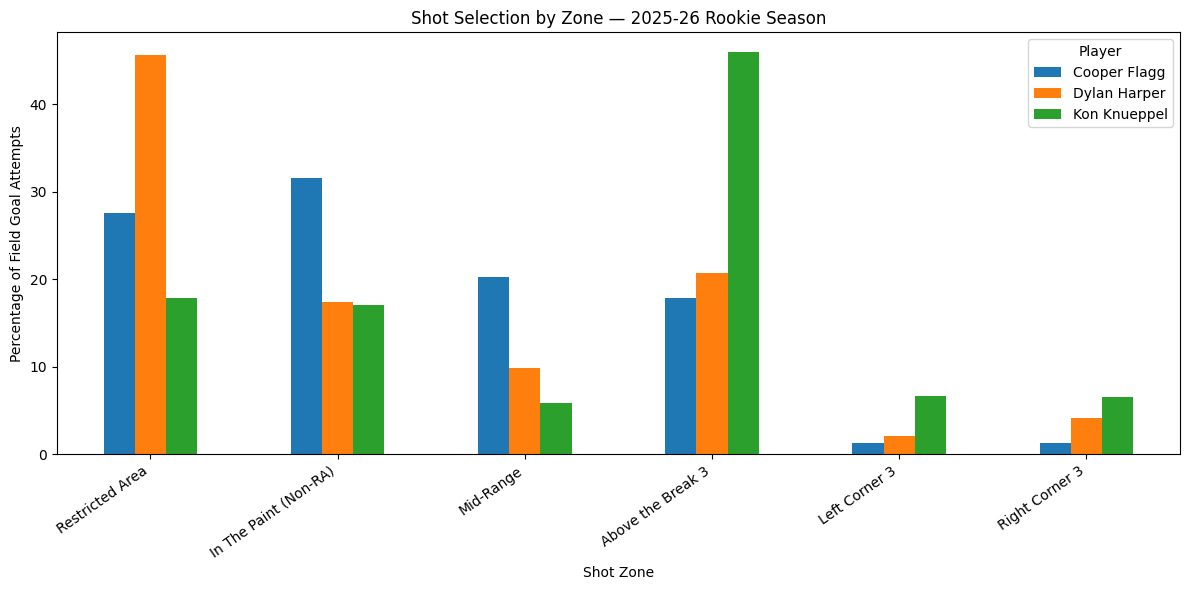

In [12]:
zone_order = [
    "Restricted Area",
    "In The Paint (Non-RA)",
    "Mid-Range",
    "Above the Break 3",
    "Left Corner 3",
    "Right Corner 3"
]

plot_df = zone_comparison_df.loc[zone_order]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Shot Selection by Zone — 2025-26 Rookie Season")
plt.xlabel("Shot Zone")
plt.ylabel("Percentage of Field Goal Attempts")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Player")
plt.tight_layout()

plt.savefig(
    "../Visuals/shot_selection_by_zone.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
summary_df.to_csv(
    "../Data/rookie_shot_selection_summary.csv",
    index=False
)

print("Summary data saved successfully.")

Summary data saved successfully.


## Key Findings

The three rookies displayed distinctly different shot-selection profiles during the 2025-26 regular season.

### Cooper Flagg — Balanced Scoring Profile
Flagg had the most balanced distribution of the three players. He took 31.6% of his attempts from the non-restricted paint and 20.3% from mid-range, while only 20.4% of his total attempts were three-pointers. His 11.0-foot average shot distance reflects a scoring profile built primarily around interior and intermediate-range opportunities.

### Dylan Harper — Rim-Oriented Attacker
Harper was the most rim-focused player in the comparison. Approximately 45.6% of his field goal attempts came from the restricted area, the highest rate among the three rookies. He also had the shortest average shot distance at 10.2 feet and produced 1.102 points per field goal attempt.

### Kon Knueppel — Perimeter-Oriented Shooter
Knueppel had the clearest perimeter-oriented profile. Three-pointers accounted for 59.2% of his field goal attempts, including 45.9% from above the break. His average shot distance of 17.4 feet was substantially longer than either Flagg or Harper. Despite the more difficult shot profile, Knueppel generated 1.202 points per field goal attempt, the highest mark of the three players.

### Overall Comparison
The analysis highlights three different offensive approaches: **Flagg's balanced interior and mid-range game, Harper's rim pressure, and Knueppel's high-volume perimeter shooting.** Knueppel's combination of three-point volume and efficiency produced the highest points-per-shot figure, demonstrating why field goal percentage alone does not fully capture scoring efficiency.

## Limitations

This analysis focuses exclusively on field goal attempts from the 2025-26 NBA regular season and does not account for free throws, turnovers, assists, or other aspects of offensive performance.

Shot-zone efficiency should also be interpreted alongside attempt volume. Some zones contain relatively small sample sizes, particularly corner three-point attempts for certain players, which can produce large percentage differences from only a few made or missed shots.

Additionally, points per shot in this analysis measures points generated from field goal attempts only and should not be interpreted as true shooting percentage or overall offensive efficiency.